In [1]:
# Import Data Manipulation Libraries
import numpy as np
import pandas as pd

# Import Data Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import Filter warning Libraries
import warnings
warnings.filterwarnings('ignore')

# Import Logging
import logging
logging.basicConfig(level = logging.INFO,
                    filename = 'supplychain.log',
                    filemode = 'w',
                    format = '%(asctime)s - %(message)s - %(levelname)s',
                    force = True)

# Import OrderedDict Function
from collections import OrderedDict

# Importing Machine Learning models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler,MinMaxScaler,LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,BaggingClassifier,AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [2]:
# Data Ingestion 
data = pd.read_csv(r'E:\TitanicPeopleSurvival_PredictionModel\data\raw\Titanic_Dataset.csv')
data.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title,AgeGroup,CabinDeck,Ticket,Survived
0,1,3,male,43.2,4,3,23.01,S,8,0,Miss,Adult,Unknown,PC 27225,0
1,2,3,male,21.4,2,0,157.46,C,3,0,Mr,YoungAdult,Unknown,SC 257787,1
2,3,3,female,47.2,1,4,131.88,S,6,0,Mr,Adult,Unknown,CA 147316,1
3,4,1,male,15.7,0,4,3.42,S,5,0,Dr,Teen,Unknown,PC 710570,0
4,5,1,male,49.6,2,0,54.24,S,3,0,Miss,Adult,Unknown,PC 620176,0


In [3]:
# Checking Data if it consists any null values in it 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  15000 non-null  int64  
 1   Pclass       15000 non-null  int64  
 2   Sex          15000 non-null  object 
 3   Age          15000 non-null  float64
 4   SibSp        15000 non-null  int64  
 5   Parch        15000 non-null  int64  
 6   Fare         15000 non-null  float64
 7   Embarked     15000 non-null  object 
 8   FamilySize   15000 non-null  int64  
 9   IsAlone      15000 non-null  int64  
 10  Title        15000 non-null  object 
 11  AgeGroup     14705 non-null  object 
 12  CabinDeck    15000 non-null  object 
 13  Ticket       15000 non-null  object 
 14  Survived     15000 non-null  int64  
dtypes: float64(2), int64(7), object(6)
memory usage: 1.7+ MB


In [4]:

# Checking the skewness, IQR, min, max values and more 
# First we segregate the numerical and categorical columns

numerical_col = data.select_dtypes(exclude = 'object').columns
categorical_col = data.select_dtypes(include = 'object').columns

# Numerical Descriptive stats

numerical_stats = []
Q1 = data[numerical_col].quantile(0.25)
Q3 = data[numerical_col].quantile(0.75)
IQR = Q3 - Q1
LW = Q1 - 1.5 * IQR
UW = Q3 + 1.5 * IQR
Outlier_Count = (data[numerical_col] < LW) | (data[numerical_col] > UW)
Outlier_Percentage = (Outlier_Count.sum()/len(data)) * 100

for i in numerical_col:
    num_stats = OrderedDict ({
        "Feature" : i,
        "Count" : data[i].count(),
        "Maximum" : data[i].max(),
        "Minimum" : data[i].min(),
        "Mean" : data[i].mean(),
        "Median" : data[i].median(),
        "Q1" : Q1,
        "Q3" : Q3,
        "IQR" : IQR,
        "Lower Whisker" : LW,
        "Upper Whisker" : UW,
        "Outlier_Count" : Outlier_Count,
        "Outlier_Percentage" : Outlier_Percentage,
        "Skewness" : data[i].skew(),
        "Kurtosis" : data[i].kurt(),
        "Standard Deviation" : data[i].std()
        })
    numerical_stats.append(numerical_stats)
    numerical_stats_report = pd.DataFrame(numerical_stats)
    print(numerical_stats_report)


               0
0  [[[[[...]]]]]
                                                   0  \
0  [[[[[...], [...]], [[...], [...]]], [[[...], [...   
1  [[[[[...], [...]], [[...], [...]]], [[[...], [...   

                                                   1  
0  [[[[[...], [...]], [[...], [...]]], [[[...], [...  
1  [[[[[...], [...]], [[...], [...]]], [[[...], [...  
                                                   0  \
0  [[[[[...], [...], [...]], [[...], [...], [...]...   
1  [[[[[...], [...], [...]], [[...], [...], [...]...   
2  [[[[[...], [...], [...]], [[...], [...], [...]...   

                                                   1  \
0  [[[[[...], [...], [...]], [[...], [...], [...]...   
1  [[[[[...], [...], [...]], [[...], [...], [...]...   
2  [[[[[...], [...], [...]], [[...], [...], [...]...   

                                                   2  
0  [[[[[...], [...], [...]], [[...], [...], [...]...  
1  [[[[[...], [...], [...]], [[...], [...], [...]...  
2  [[[[[...], [..

In [5]:
categorical_stats = []

for i in categorical_col:
    cat_stats = OrderedDict({
        "Feature":i,
        "Count":data[i].count(),
        "Unique_Count":data[i].nunique(),
        "Mode":data[i].mode(),
        "Value_Counts":data[i].value_counts()
    })
    categorical_stats.append(cat_stats)
    categorical_stats_report = pd.DataFrame(categorical_stats)
    print(categorical_stats_report)

  Feature  Count  Unique_Count                                Mode  \
0     Sex  15000             2  0    male
Name: Sex, dtype: object   

                                        Value_Counts  
0  Sex
male      9624
female    5376
Name: count,...  
    Feature  Count  Unique_Count                                  Mode  \
0       Sex  15000             2    0    male
Name: Sex, dtype: object   
1  Embarked  15000             3  0    S
Name: Embarked, dtype: object   

                                        Value_Counts  
0  Sex
male      9624
female    5376
Name: count,...  
1  Embarked
S    10813
C     2855
Q     1332
Name...  
    Feature  Count  Unique_Count                                  Mode  \
0       Sex  15000             2    0    male
Name: Sex, dtype: object   
1  Embarked  15000             3  0    S
Name: Embarked, dtype: object   
2     Title  15000             5    0    Mr
Name: Title, dtype: object   

                                        Value_Counts  
0  Sex
ma

In [6]:
# Removing the unwanted columns that will be not in use for the data as well as for the machine learning model

data.drop(columns = ['PassengerId','CabinDeck','Ticket','Title','AgeGroup'],inplace=True)
data.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Survived
0,3,male,43.2,4,3,23.01,S,8,0,0
1,3,male,21.4,2,0,157.46,C,3,0,1
2,3,female,47.2,1,4,131.88,S,6,0,1
3,1,male,15.7,0,4,3.42,S,5,0,0
4,1,male,49.6,2,0,54.24,S,3,0,0


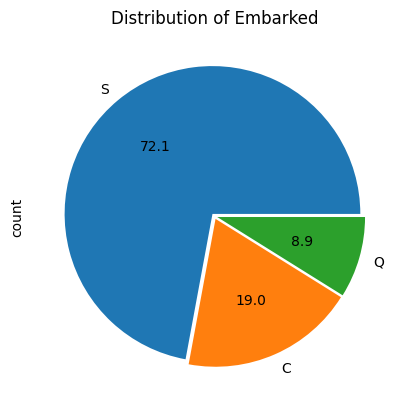

In [8]:
data['Embarked'].value_counts().plot(kind = 'pie',
                                   autopct = '%0.1f',
                                   explode = [0.02,0.02,0.02]
                                   )
plt.title('Distribution of Embarked')
plt.show()

In [9]:
# dataset for Southampton : S
Southampton_data = data[data['Embarked'] == 'S']

# People who boarded their from southampton 'S' and who is survived i.e 1

Survived_Data_Southampton = data[(data['Embarked'] == 'S') & (data['Survived'] == 1)]

# People who boarded their from southampton 'S' and who not survived i.e 0

Notsurvived_Data_Southampton = data[(data['Embarked'] == 'S') & (data['Survived'] == 0)]

Southampton_data.to_csv('Southampton Total Data.csv')
Survived_Data_Southampton.to_csv('Survived Data Southampton.csv')
Notsurvived_Data_Southampton.to_csv('Not Survived Data Southampton.csv')

In [10]:
#Dataset for Cherbourg : C
Cherbourg_data = data[data['Embarked'] == 'C']

# People who boarded their from chestburg 'C' and who is survived i.e 1

Cherbourg_data_survived = data[(data['Embarked'] == 'C') & (data['Survived'] == 1)]

# # People who boarded their from chestburg 'C' and who is survived i.e 0

Cherbourg_data_notsurvived = data[(data['Embarked'] == 'C') & (data['Survived'] == 0)]

Cherbourg_data.to_csv('Cherbourg Total Data.csv')
Cherbourg_data_survived.to_csv('Survived Data Cherbourg.csv')
Cherbourg_data_notsurvived.to_csv('Not Survived Cherbourg.csv')

In [11]:
# Dataset for Queenstown : Q
Queenstown_data = data[data['Embarked'] == 'Q']

# People who boarded thier journey form Queenstown 'Q' and who survived i.e 1

Queenstown_data_survived = data[(data['Embarked'] == 'Q') & (data['Survived'] == 1)]

# People who boarded thier journey from Queenstown 'Q' and who does not survived i.e 0

Queenstown_notsurvived_data = data[(data['Embarked'] == 'Q') & (data['Survived'] == 0)]

# Making a CSV file for each of them

Queenstown_data.to_csv('Queentown Total Data.csv')
Queenstown_data_survived.to_csv('Survived Data Queenstown.csv')
Queenstown_notsurvived_data.to_csv('Not Survived Queenstown.csv')

In [12]:
# Checking Class wise ditribution whether thay have survived or not accordingly.

First_Class_Data = data[data['Pclass'] == 1]

# People who are from 1st class and who survived i.e 1

Survived_FirstClass_Data = data[(data['Pclass'] == 1) & (data['Survived'] == 1)]

# People who are from 1st class and who not survived i.e 0

Notsurvived_Firstclass_Data = data[(data['Pclass'] == 1) & (data['Survived'] == 0)]

# Making a CSV file for each of them

First_Class_Data.to_csv('First Class Data.csv')
Survived_Data_Southampton.to_csv('First Class Survived.csv')
Notsurvived_Firstclass_Data.to_csv('First Class Not survived.csv')

In [13]:
# Checking second class data
Second_Class_Data = data[data['Pclass'] == 2]

# People who are from 2nd class and who survived i.e 1

Survived_SecondClass_Data = data[(data['Pclass'] == 2) & (data['Survived'] == 1)]

# People who are from 2nd class and who not survived i.e 0

Notsurvived_SecondClass_Data = data[(data['Pclass'] == 2) & (data['Survived'] == 0)]

# Making a CSV file for each data

Second_Class_Data.to_csv('Second Class Data.csv')
Survived_SecondClass_Data.to_csv('Second Class Survived.csv')
Notsurvived_SecondClass_Data.to_csv('Not Survived Second Class.csv')

In [14]:
# Checking for the 3rd class
Third_Class_Data = data[data['Pclass'] == 3]

# People who are from 3rd class and who survived i.e 1

Survived_ThirdClass_Data = data[(data['Pclass'] == 3) & (data['Survived'] == 1)]

# People who are from 3rd class and not survived i.e 0

Notsurvived_ThirdClass_Data = data[(data['Pclass'] == 3) & (data['Survived'] == 0)]

# Making a CSV file for ach of them

Third_Class_Data.to_csv('Third Class Data.csv')
Survived_ThirdClass_Data.to_csv('Survived Third Class.csv')
Notsurvived_ThirdClass_Data.to_csv('Not Survived Third Class.csv')

In [15]:
# Controlling Data Leakage
'''
1. Split the Dataset into X and y
2. Split the Dataset into Train and Test Sets
3. Use Encoding Techniques on Categorical Features
4. Use Scaling Techniques on Numerical Features
5. Use SMOTE
'''
# 1. Split the Dataset into X and y
X = data.drop('Survived',axis=1)
y = data['Survived']
# 2. Split the Dataset into Train and Test Sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.3,
                                                    random_state = 1)
# 3. Use Encoding Techniques on Categorical Features

# Segregate Categorical and Numerical Features
numerical_col = X.select_dtypes(exclude = 'object').columns
categorical_col = X.select_dtypes(include = 'object').columns
# Apply Label Encoding on Categorical Features
le = LabelEncoder()
for col in categorical_col:
    X_train[col] = le.fit_transform(X_train[col])  # Seen Data
    X_test[col] = le.transform(X_test[col])           # Unseen Data
# 4. Use Scaling Techniques on Numerical Features
sc = RobustScaler()
X_train[numerical_col] = sc.fit_transform(X_train[numerical_col])   # Seen Data
X_test[numerical_col] = sc.transform(X_test[numerical_col])   # Unseen Data

# 5. Use SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)  # Seen Data

In [16]:
# KNN Classifier
from sklearn.neighbors import KNeighborsClassifier
'''
1. n_neighbors: 5 # Default value
2. p = 2 # Default value
3. n_jobs = none # Default value
-----------------------------------------
-Knn suffer with curse of Dimensionality
to tackel this issue following steps is necessary
------------------------------------------
1. reduce the High Dimension to low Dimension using PendingDeprecationWarning
'''


knn = KNeighborsClassifier(n_neighbors=10,
                           p = 2,
                           n_jobs = None).fit(X_train, y_train)

y_pred = knn.predict(X_test)
acc_knn = classification_report(y_test, y_pred)
print(acc_knn)

              precision    recall  f1-score   support

           0       0.65      0.62      0.63      2876
           1       0.38      0.41      0.39      1624

    accuracy                           0.54      4500
   macro avg       0.51      0.51      0.51      4500
weighted avg       0.55      0.54      0.55      4500



In [17]:
# SVC = Support Vector Classifier

from sklearn.svm import SVC

'''
1. SVM is used when there will be high dimension in the data
2. It used Kerenel function approach to evaluate answers in batches
3. This also uses kfold approach to evaluate the answer
---------------------------------------------------------------------
1. Kernel function : 'rbf' # default value
2. degree = 3  # Default value
3. gamma = 'scale' # Default value
4. coef0 = 0.0 # Default value
'''
svc = SVC().fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)
svc_acc = classification_report(y_test, y_pred_svc)
print(svc_acc)

              precision    recall  f1-score   support

           0       0.65      0.39      0.49      2876
           1       0.37      0.62      0.46      1624

    accuracy                           0.48      4500
   macro avg       0.51      0.51      0.48      4500
weighted avg       0.55      0.48      0.48      4500



In [18]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Bagging Classifier": BaggingClassifier(),
    "KNeighborsClassifier": KNeighborsClassifier(),
    "SVC":SVC()}

for model_name, model in models.items():
    model.fit(X_train, y_train)  # Seen Data
    y_pred = model.predict(X_test)   # Unseen Data
    print(f"Model: {model_name}")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("-" * 50)

Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.64      0.45      0.53      2876
           1       0.36      0.55      0.44      1624

    accuracy                           0.49      4500
   macro avg       0.50      0.50      0.49      4500
weighted avg       0.54      0.49      0.50      4500

Confusion Matrix:
[[1306 1570]
 [ 725  899]]
--------------------------------------------------
Model: Decision Tree
              precision    recall  f1-score   support

           0       0.64      0.57      0.60      2876
           1       0.36      0.43      0.39      1624

    accuracy                           0.52      4500
   macro avg       0.50      0.50      0.49      4500
weighted avg       0.54      0.52      0.52      4500

Confusion Matrix:
[[1628 1248]
 [ 931  693]]
--------------------------------------------------
Model: Random Forest
              precision    recall  f1-score   support

           0       0.64      0